In [1]:
import mne
import os
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
#création d'un dataset avec sample
sample_data_folder = mne.datasets.sample.data_path()

In [24]:
#construction du chemin vers le fichier .fif
raw_fname = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

In [ ]:
#lecture des métadonnées, False
raw = mne.io.read_raw_fif(raw_fname, preload = False)
#Filtrage des canaux EEG, EOG et les stimulation
raw.pick_types(meg = False, eeg = True, eog = True, stim = True)
#Chargement des données en mémoire
raw.load_data()
print(raw.info)

### Prétraitement : Nettoyage et filtrage des données
D'après Gramfort et al.(2013) le signal EEG brut capte l'activité mais est également sujet a de nombreuses interférences provenant de l'environnement ou de l'activité musculaire. Pour isoler les fréquences utiles à l'analyse, j'applique deux filtres : un passe-haut pour l'ICA, car il est sensible aux basses fréquences, à 1.0 Hz pour entraîner l'ICA dans les meilleures conditions puis un filtrage passe-bas (Low-pass filter) à 40.0 Hz, ce seuil permet de supprimer les interférences du réseau électrique (50Hz) ainsi que les bruits de haute fréquence, tout en préservant les rythmes cérébraux physiologiques.
Méthodologie adapté de Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python, Frontiers in Neuroscience

In [ ]:
# Filtrage préservant les ondes lentes(pour les ERP)
raw.filter(l_freq= 0.1, h_freq = 40.0, fir_design = 'firwin') #Hz
# Création d'une copie dédiée à l'entraînement de l'ICA
raw_for_ica = raw.copy()
#Application du filtre sur les données copiées
raw_for_ica.filter(l_freq= 1.0, h_freq = 40.0, fir_design = 'firwin') #Hz


### Correction des interférences oculaire (ICA)

J'utilise l'algorithme FastICA(Hyvärinen, 1999) pour sa rapidité de convergence. Il extrait des composantes statistiquement indépendantes ce qui permet d'identifier les artefacts oculaire. J'isole ensuite les composantes liées aux clignements d'yeux en fixant $n$ = 20 composantes pour assurer une décomposition stable, sans supprimer les données correspondantes.

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 8.2s.


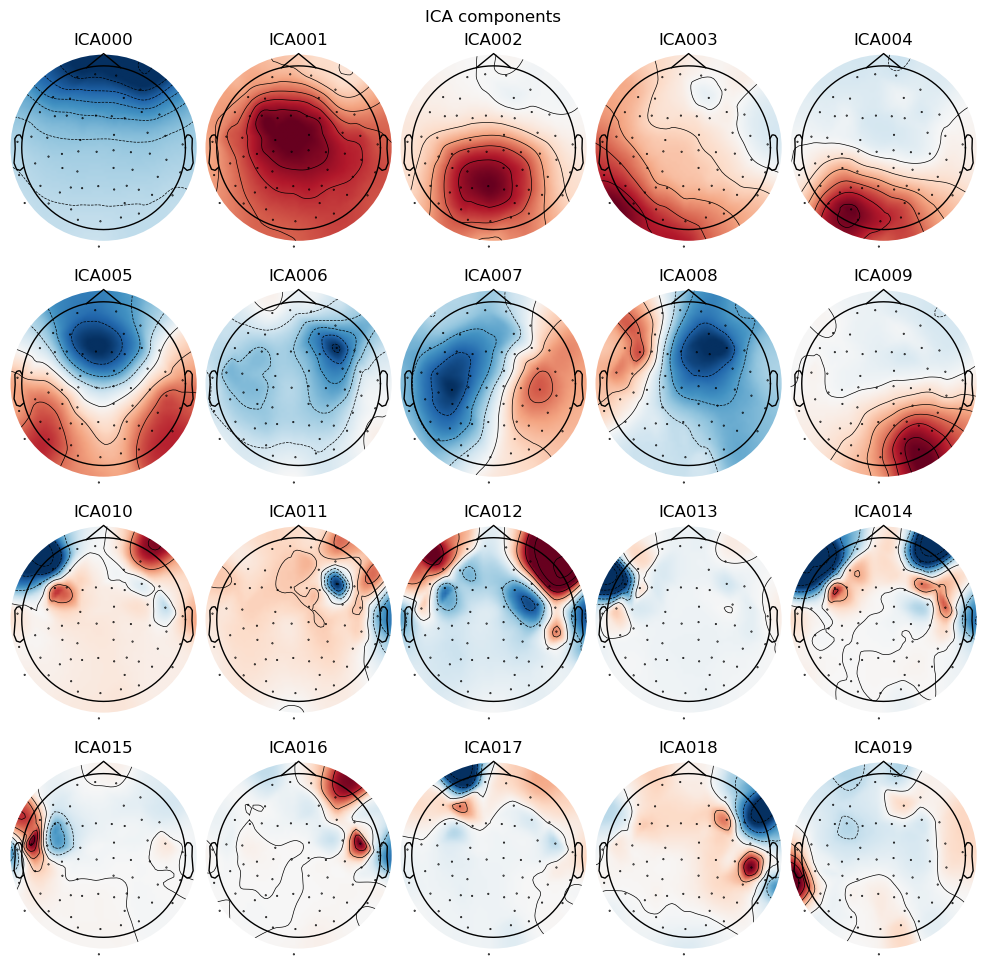

In [7]:
#Initialisation de l'ICA
ica = mne.preprocessing.ICA(n_components = 20, random_state=42, method='fastica')
# entraînement de l'ica
ica.fit(raw_for_ica)
#Visualisation des propriétés des composantes
ica.plot_components();

In [ ]:
#on vérifie le signal de la composante 0 dans le temps
ica.plot_sources(raw_for_ica)

In [ ]:
#On définit la composante à supprimer
ica.exclude = [0]
#on applique la suppression sur une copie des données
#création de la copie avec 'raw_clean'
raw_clean = raw.copy()
ica.apply(raw_clean)

In [ ]:
#affichage du signal original (~14.430s)
raw.plot(start = 10, duration = 10, title = "Signal pollué")
#Affichage du signal après ICA
raw_clean.plot(start = 10, duration = 10, title = "Signal nettoyé (ICA000 supprimée)")

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 59 PCA components


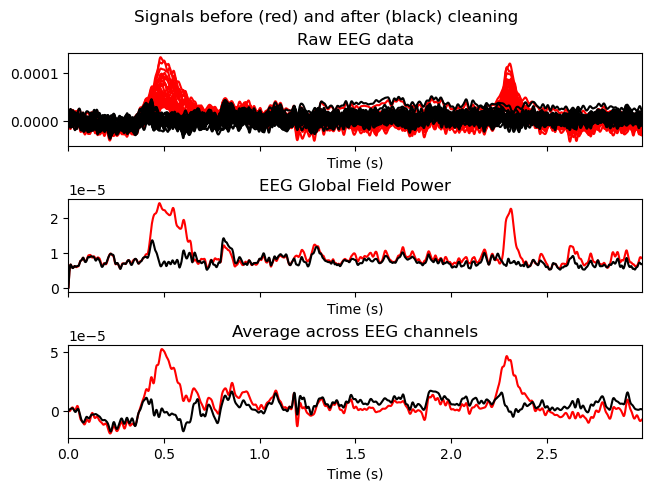

In [11]:
#Visualisation de la différence entre les données brute et les données propre
ica.plot_overlay(raw, exclude=[0], picks='eeg');

### Nettoyage des parasites physiologiques (ICA)
En suivant le protocole de **Gramfort et al. (2013)**, j'ai effectué une analyse en composantes indépendantes (ICA) pour isoler les signaux non-cérébraux. La composante ICA000 a été identifiée comme un artefact oculaire en raison de sa topographie frontale et de sa signature temporelle (pics de forte amplitude). La comparaison avant/après (*Overlay*) confirme que l'exclusion de cette composante supprime les déflexions oculaires tout en préservant l'intégrité du signal EEG environnant. Le signal raw_clean obtenu constitue la base nettoyée pour l'analyse des potentiels évoqués.

### Segmentation des données (Epoching)
Une fois le signal continu nettoyé (raw_clean), je repère les instants précis des stimuli en lisant le trigger channel STI 014, qui encode les événements pendant l'enregistrement.
Ensuite je découpe le signal en segments de durée égale (de -0.3s à 0.7s autour du stimulus) pour chaque catégorie définie dans le dictionnaire d'événements. 

In [12]:
events = mne.find_events(raw_clean, stim_channel="STI 014")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


In [13]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "face": 5,
    "buttonpress": 32,
}
reject = {'eeg': 150e-6}

In [15]:
epochs = mne.Epochs(
    raw_clean,
    events,
    tmin=-0.3,
    tmax=0.7,
    event_id=event_dict,
    reject = reject,
    preload=True
)


Not setting metadata
320 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 320 events and 601 original time points ...
    Rejecting  epoch based on EEG : ['EEG 008']
    Rejecting  epoch based on EEG : ['EEG 008']
2 bad epochs dropped


In [16]:
print(epochs.event_id)

{'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4, 'face': 5, 'buttonpress': 32}


In [17]:
del raw_clean

In [ ]:
print(epochs)

Le résultat affiche un découpage équilibré d'environ 70 essais valides pour les conditions auditives et visuelles principales, ce qui est largement suffisant pour faire ressortir un potentiel évoqué.

### Potentiels Évoqués (Evoked) : La Réponse Auditive
Pour isoler la réponse cérébrale au stimulus sonore du bruit de fond (activité cérébrale spontanée), je calcule la moyenne mathématique de toutes les époques (Evoked) pour la condition auditory/left car le signal neuronal est cohérent d'un essai a l'autre, contrairement à l'activité aléatoire qui s'annule.


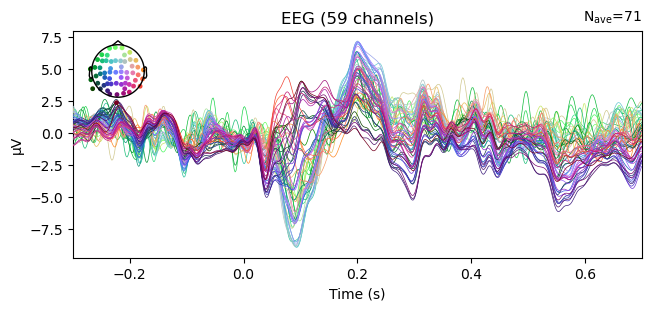

In [19]:
evoked_aud_left = epochs['auditory/left'].average()
#graphique
evoked_aud_left.plot();

Le butterfly plot obtenu montre une déviation négative claire vers 100 ms (N100) suivie d'une déflexion positive vers 200 ms (P200). 
Ces ondes, caractéristiques du traitement auditif primaire, valident la qualité du prétraitement.

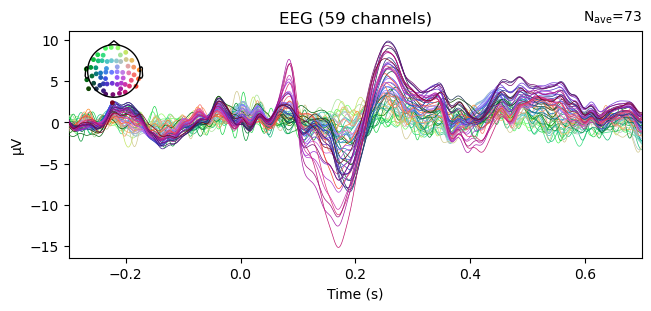

In [20]:
#On calcule la moyenne pour la vision à gauche
evoked_vis_left = epochs['visual/left'].average()
#graphique vision gauche 
evoked_vis_left.plot();


### Comparaison Auditif vs Visuel : Temporelle et Spatiale


combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


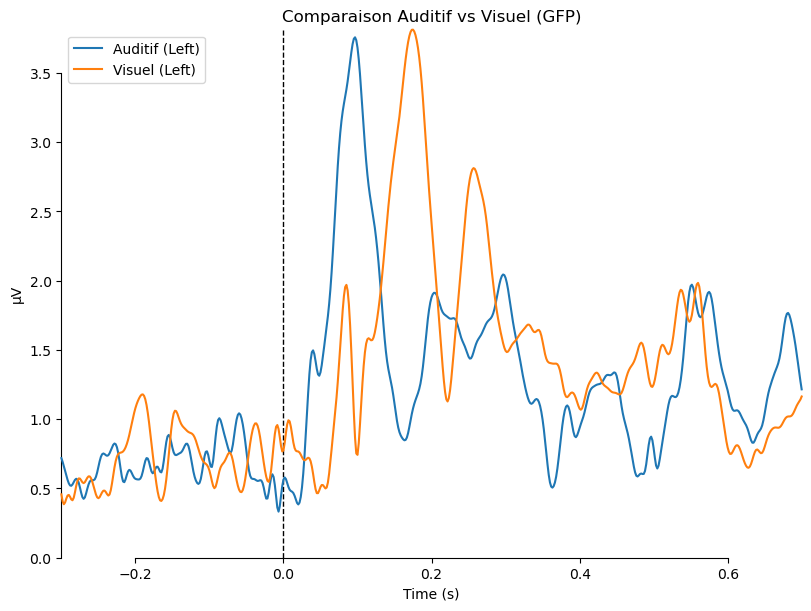

In [21]:
evoked_vis_left = epochs['visual/left'].average()

#dico
evokeds_dict = {    'Auditif (Left)': evoked_aud_left, 'Visuel (Left)': evoked_vis_left, }
#Comparaison globale sur les canaux EEG
mne.viz.plot_compare_evokeds(evokeds_dict, picks='eeg', title='Comparaison Auditif vs Visuel');

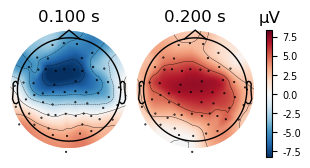

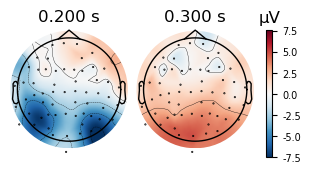

In [22]:
# Tracer la carte topographique (topomap) 100ms et 200ms
evoked_aud_left.plot_topomap(times = [0.1, 0.2], ch_type = 'eeg');
evoked_vis_left.plot_topomap(times = [0.2, 0.3], ch_type = 'eeg');

L'observation des courbes superposées met en évidence des latences de réponses très différentes selon le stimulus. Pour mieux comprendre la dynamique du signal, j'ai projeté cette activité sur une carte 2D des capteurs. À 100 ms, l'analyse spatiale confirme la réponse auditive, avec une activité localisée sur les régions temporales et fronto-centrales. À 200 ms, j'observe une positivité plus étendue, centrée sur les régions centro-pariétales.

### Conclusion de l'analyse : L'Onde de Différence (Contraste)
Pour isoler spécifiquement le réseau neuronal dédié à l'audition, je soustrais l'activité visuelle de l'activité auditive (Poids : 1 et -1). Cette "onde de différence" élimine les processus cognitifs communs aux deux tâches (comme l'attention générale).

No projector specified for this dataset. Please consider the method self.add_proj.


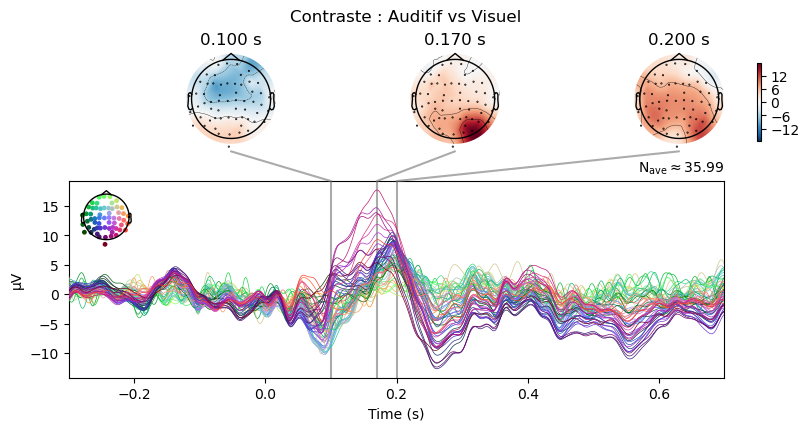

In [23]:
# 1. On calcule la moyenne pour la vision à gauche
evoked_vis_left = epochs['visual/left'].average()

# 2. On fait la soustraction : Auditif - Visuel
evoked_diff = mne.combine_evoked([evoked_aud_left, evoked_vis_left], weights=[1, -1])

# 3. Affichage du résultat avec les courbes et la topographie
evoked_diff.plot_joint(times=[0.1, 0.17, 0.2], title="Contraste : Auditif vs Visuel");

### Bibliographie

**Gramfort, A., Luessi, M., Larson, E., Engemann, D. A., Strohmeier, D., Brodbeck, C., Goj, R., Jas, M., Brooks, T., Parkkonen, L., & Hämäläinen, M. S.** (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience*, *7*, https://doi.org/10.3389/fnins.2013.00267

**Hyvärinen, A.** (1999). Fast and robust fixed-point algorithms for independent component analysis. *IEEE Transactions on Neural Networks*, *10*(3), https://doi.org/10.1109/72.761722

**MNE-Python Developers.** (2026). *MNE-Python documentation*. MNE. https://mne.tools/

 ## Travaux en cours : 
 affinement des cellules markdown